In [4]:
import sys
sys.path.insert(0, r"C:\Users\sonia\AppData\Roaming\Python\Python312\site-packages")



In [6]:
# Step 1: Import required libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [7]:
# Step 2: Load the dataset from the CSV file
# Replace '/content/your_dataset.csv' with your actual CSV file path
file_path = 'Raw file data.csv'
data = pd.read_csv(file_path)

# Display the first 5 rows of the dataset
data.head()


,Text,Label
0,May be Great. Blessings of Allahoo always,0
1,How does a deceased person receive anything mu...,0
2,There is no way over 20 million Americans are ...,0
3,Even MORE annoying is someone like me who has ...,0
4,why should I do this?,0


In [12]:
# Step 3: Check dataset info - data types and null values
data.info()

# Check for missing values in each column
data.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    19998 non-null  object
 1   Label   19998 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


Text     0
Label    0
dtype: int64

In [14]:
# Step 4: Remove duplicate rows and rows with missing values
print(f"Original dataset size: {data.shape}")
data.drop_duplicates(inplace=True)
data.dropna(inplace=True)
print(f"Dataset size after cleaning: {data.shape}")


Original dataset size: (19998, 2)
Dataset size after cleaning: (19042, 2)


In [16]:
# Step 4.1: Text Normalization – Lowercasing, Removing Special Characters, URLs, and Stopwords
import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def normalize_text(text):
    # Lowercase the text
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions and hashtags
    text = re.sub(r'@\w+|#','', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply the function to the Text column
data['Text'] = data['Text'].apply(normalize_text)

# Preview cleaned text
data['Text'].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sonia\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


0                   may great blessings allahoo always
1    deceased person receive anything much less soc...
2                   way 20 million americans 100 older
3    even annoying someone like application limbo h...
4                                                     
Name: Text, dtype: object

In [20]:
# Step 8: Tokenize and Pad the Cleaned Text
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize tokenizer
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(data['Text'])  # Use normalized text

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(data['Text'])

# Pad sequences to ensure consistent length
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# Print shape of the padded data
print(f"Padded Sequences Shape: {padded_sequences.shape}")


Padded Sequences Shape: (19042, 100)


In [22]:
# Step 9: Split Data into Training and Testing Sets
from sklearn.model_selection import train_test_split

# Features (X) and Labels (y)
X = padded_sequences
y = data['Label'].values

# Split the data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print shapes to confirm
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (15233, 100)
X_test shape: (3809, 100)
y_train shape: (15233,)
y_test shape: (3809,)


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize and fit TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(data['Text'])

# Shape
print(f"TF-IDF shape: {X_tfidf.shape}")


TF-IDF shape: (19042, 5000)


In [26]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train_tfidf)
y_pred_rf = rf_model.predict(X_test_tfidf)

print(" Random Forest Accuracy:", accuracy_score(y_test_tfidf, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_tfidf, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_tfidf, y_pred_rf))


 Random Forest Accuracy: 0.9574691520084011

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      1913
           1       0.97      0.95      0.96      1896

    accuracy                           0.96      3809
   macro avg       0.96      0.96      0.96      3809
weighted avg       0.96      0.96      0.96      3809


Confusion Matrix:
 [[1849   64]
 [  98 1798]]


In [30]:
def normalize_text(text):
    import re, string
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))

    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#", '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# 🔍 Custom input text
sample_text = "In the ever-expanding domain of machine learning, the utilization of data continues to be of paramount importance. Data, in its raw form, represents the foundation upon which predictive algorithms build their understanding of the world. ."
# 🧼 Normalize + TF-IDF transform
cleaned_text = normalize_text(sample_text)
sample_vector = tfidf.transform([cleaned_text])

# ✅ Predict with Random Forest
prediction = rf_model.predict(sample_vector)
label = "AI-generated" if prediction[0] == 1 else "Human-written"

#  Output
print("Cleaned Text:", cleaned_text)
print(f"Predicted Label: {label} ({prediction[0]})")


Cleaned Text: everexpanding domain machine learning utilization data continues paramount importance data raw form represents foundation upon predictive algorithms build understanding world
Predicted Label: AI-generated (1)


In [32]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
import torch
import pandas as pd


In [63]:
# Assuming `data` already has 'Text' and 'Label'
df = data.copy()
df = df[['Text', 'Label']].dropna()
df['Text'] = df['Text'].astype(str)

# Convert to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(df)


In [33]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(example):
    return tokenizer(example["Text"], truncation=True)

tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)


NameError: name 'hf_dataset' is not defined

In [67]:
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.2)


In [69]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [59]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert-results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

In [61]:
# Cell: Define Data Collator
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Data collator ready")


✅ Data collator ready


In [63]:
# Rename 'Label' → 'labels'
tokenized_dataset = tokenized_dataset.rename_column("Label", "labels")

# Confirm new features
print(tokenized_dataset['train'].features)


{'Text': Value(dtype='string', id=None), 'labels': Value(dtype='int64', id=None), '__index_level_0__': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}


In [65]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # Stop after 2 evals with no improvement
)
print("Trainer initialized with early stopping")


NameError: name 'small_train' is not defined

In [67]:
# Reduce dataset to small sample (e.g., 500 training, 100 testing)
small_train = tokenized_dataset['train'].shuffle(seed=42).select(range(2000))
small_test = tokenized_dataset['test'].shuffle(seed=42).select(range(500))

# Update Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
)
print(" Trainer initialized with small dataset")


C:\Users\sonia\AppData\Local\Temp\ipykernel_1272\4077686616.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


 Trainer initialized with small dataset


In [87]:
# Cell: Start Training
trainer.train()
print(" Training completed")


Epoch,Training Loss,Validation Loss
1,0.118300,0.083828
2,0.034000,0.085634
3,0.010500,0.095463


 Training completed


In [89]:
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Evaluate using built-in method
metrics = trainer.evaluate()
print(" Evaluation Metrics from Trainer:")
print(metrics)

# Step 2: Get predictions from test set
predictions = trainer.predict(tokenized_dataset['test'])
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# Step 3: Print Accuracy
acc = accuracy_score(true_labels, pred_labels)
print(f"\n Accuracy Score: {acc:.4f}")

# Step 4: Print Classification Report (Precision, Recall, F1)
print("\n Classification Report:")
print(classification_report(true_labels, pred_labels))


 Evaluation Metrics from Trainer:
{'eval_loss': 0.08382775634527206, 'eval_runtime': 13.4238, 'eval_samples_per_second': 37.247, 'eval_steps_per_second': 4.693, 'epoch': 3.0}

 Accuracy Score: 0.9829

 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1873
           1       0.98      0.99      0.98      1936

    accuracy                           0.98      3809
   macro avg       0.98      0.98      0.98      3809
weighted avg       0.98      0.98      0.98      3809



In [69]:
model.save_pretrained("bert_finetunedfixed_model")
tokenizer.save_pretrained("bert_finetunedfixed_model")
print(" Model and tokenizer saved!")


SafetensorError: Error while serializing: IoError(Os { code: 1224, kind: Uncategorized, message: "The requested operation cannot be performed on a file with a user-mapped section open." })

In [71]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load saved model and tokenizer
model_path = "bert_finetunedfixed_model"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# Put model in evaluation mode
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [43]:
do not run this pls

from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load saved model and tokenizer
model_path = "bert_finetuned1_model"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# Put model in evaluation mode
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [73]:
def predict_with_bert(text):
    cleaned_text = normalize_text(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred_label = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_label].item()

    label = "AI-generated" if pred_label == 1 else "Human-written"
    return label, confidence, cleaned_text
sample_text = "then she followed her and attacked which made her to lose trap"
label, confidence, cleaned = predict_with_bert(sample_text)

print(" Cleaned Text:", cleaned)
print(f" Predicted Label: {label} ({confidence:.2%} confidence)")


 Cleaned Text: followed attacked made lose trap
 Predicted Label: Human-written (99.98% confidence)


In [99]:
#BERT + RANDOM
# Cell 1: Imports
import numpy as np
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import joblib

# Cell 2: Load BERT base model + tokenizer (on CPU)
device = torch.device("cpu")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')
bert.to(device)
bert.eval()  # inference mode

# Cell 3: Function to extract BERT pooled embeddings (CPU-only)
def get_bert_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = bert(**inputs)
    pooled = outputs.pooler_output  # shape: [1, 768]
    return pooled.squeeze().numpy()

# Cell 4: Load dataset (replace with your file path)
data = pd.read_csv('Raw file data.csv')  # must have 'Text' and 'Label' columns
data = data.dropna(subset=['Text', 'Label'])

# ⏳ Select a **small subset** (e.g., first 500 samples)
small_data = data.sample(n=7000, random_state=42).reset_index(drop=True)

# Cell 5: Create BERT embeddings for the subset
print(" Extracting BERT embeddings...")
X_bert = np.array([get_bert_embedding(text) for text in small_data['Text']])
y = small_data['Label'].values
print(f" Completed! Shape: {X_bert.shape}")

# Cell 6: Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bert, y, test_size=0.2, random_state=42, stratify=y
)

# Cell 7: Train Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(" Random Forest training complete")

# Cell 8: Evaluate on test set
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-score: {f1:.4f}")
print("\n Confusion Matrix:")
print(conf_matrix)
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

# Cell 9: Save the trained RF model
joblib.dump(rf, 'bert_rf_model_fixed.joblib')
print(" Random Forest model saved as 'bert_rf_model_fixed.joblib'")

# Cell 10: Predict on new samples
sample_texts = [
    "One of the reasons families avoid tourist places, specially remote/hills is this: everywhere you go, you'll find hooligans traveling in groups, drunk, driving fast, cutting corners, loud music, talking loudly, abusing, and always ready to pick a fight.",
    "Women will do insane shit. Masculinity is being the man on the railing when she does..",
    "Ugh Friday afternoon finally! You know, I was thinking about what we discussed earlier this week – getting away for the weekend. My brain is just fried from work. Any brilliant ideas, or have you come up with anything since we last talked?",
    "Yes, I have been monitoring your calendar and prevailing leisure activity trends. Based on your previous preference for nature-oriented excursions and the current favorable weather patterns in regions within a 200-kilometer radius of Hyderabad, several options have been refined"
]

sample_features = np.array([get_bert_embedding(text) for text in sample_texts])
sample_preds = rf.predict(sample_features)
sample_probs = rf.predict_proba(sample_features)[:, 1]

for text, label, prob in zip(sample_texts, sample_preds, sample_probs):
    label_str = "AI-generated" if label == 1 else "Human-written"
    print(f"\n📝 Text: {text}")
    print(f"🔹 Predicted Label: {label_str} (Label {label})")
    print(f"🔸 Confidence: {prob:.4f}")


 Extracting BERT embeddings...
 Completed! Shape: (4000, 768)
 Random Forest training complete
 Accuracy: 0.9888
 Precision: 0.9877
 Recall: 0.9901
 F1-score: 0.9889

 Confusion Matrix:
[[390   5]
 [  4 401]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       395
           1       0.99      0.99      0.99       405

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800

 Random Forest model saved as 'bert_rf_model_fixed.joblib'

📝 Text: One of the reasons families avoid tourist places, specially remote/hills is this: everywhere you go, you'll find hooligans traveling in groups, drunk, driving fast, cutting corners, loud music, talking loudly, abusing, and always ready to pick a fight.
🔹 Predicted Label: Human-written (Label 0)
🔸 Confidence: 0.4000

📝 Text: Women will do insane shit. Masculinity is bei

In [101]:
#Final Ensemble Prediction (BERT Trainer + BERT + RF)
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import joblib

# Load BERT Trainer model + tokenizer
bert_trainer_model = BertForSequenceClassification.from_pretrained('bert_finetunedfixed_model')
bert_trainer_model.eval()
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load BERT + RF model
bert_rf = joblib.load('bert_rf_model_small.joblib')
bert_rf_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_rf_bert = BertModel.from_pretrained('bert-base-uncased')
bert_rf_bert.eval()

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_trainer_model.to(device)
bert_rf_bert.to(device)

def get_bert_trainer_prediction(text):
    inputs = bert_tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = bert_trainer_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    label = np.argmax(probs)
    confidence = probs[label]
    return label, confidence

def get_bert_rf_prediction(text):
    inputs = bert_rf_tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = bert_rf_bert(**inputs)
    pooled = outputs.pooler_output.cpu().numpy()
    prob = bert_rf.predict_proba(pooled)[0][1]  # probability of class 1
    label = 1 if prob >= 0.5 else 0
    confidence = prob if label == 1 else 1 - prob
    return label, confidence

def ensemble_predict(text):
    label1, conf1 = get_bert_trainer_prediction(text)
    label2, conf2 = get_bert_rf_prediction(text)

    votes = [label1, label2]
    final_label = 1 if votes.count(1) > votes.count(0) else 0
    avg_confidence = (conf1 + conf2) / 2

    label_str = "AI-generated" if final_label == 1 else "Human-written"
    print(f"\n Text: {text}")
    print(f" BERT Trainer → Label: {label1}, Confidence: {conf1:.4f}")
    print(f" BERT + RF → Label: {label2}, Confidence: {conf2:.4f}")
    print(f" Final Ensemble → {label_str} (Label {final_label}), Avg Confidence: {avg_confidence:.4f}")

# Test sample texts
sample_texts = [
    "That presentation went sideways, and I'm just drained. What's the damage control situation like? And honestly, what's for dinner? I can't even think straight.!",
    "There's a common belief in sports that larger, more popular, or wealthier teams (like MI, backed by Reliance Industries) receive preferential treatment from officials.",
    " The accusation has become a popular meme and a go-to trolling tactic for rival fan bases. It's often used in jest, but constant repetition can make it seem like a more serious allegation to casual observers or newer fans. ",
    "You care deeply about your family, especially your dad’s health, and you’ve been so thoughtful and organized in supporting his recovery.",
    "Akshitha is an exceptional high-performance model, fine-tuned on resilience, curiosity, and compassion datasets, consistently achieving state-of-the-art results across multitask benchmarks — from advanced NLP projects to real-world family care challenges.",
    "He has gone through serious health challenges, yet he keeps fighting, holding on with courage and resilience. Even when his body is tired, his heart — both literally and emotionally — keeps pushing forward, not just for himself but for his family."
]

for text in sample_texts:
    ensemble_predict(text)



 Text: That presentation went sideways, and I'm just drained. What's the damage control situation like? And honestly, what's for dinner? I can't even think straight.!
 BERT Trainer → Label: 0, Confidence: 0.9997
 BERT + RF → Label: 0, Confidence: 0.9500
 Final Ensemble → Human-written (Label 0), Avg Confidence: 0.9748

 Text: There's a common belief in sports that larger, more popular, or wealthier teams (like MI, backed by Reliance Industries) receive preferential treatment from officials.
 BERT Trainer → Label: 1, Confidence: 0.9972
 BERT + RF → Label: 1, Confidence: 1.0000
 Final Ensemble → AI-generated (Label 1), Avg Confidence: 0.9986

 Text:  The accusation has become a popular meme and a go-to trolling tactic for rival fan bases. It's often used in jest, but constant repetition can make it seem like a more serious allegation to casual observers or newer fans. 
 BERT Trainer → Label: 1, Confidence: 0.9885
 BERT + RF → Label: 1, Confidence: 0.7100
 Final Ensemble → AI-generated (

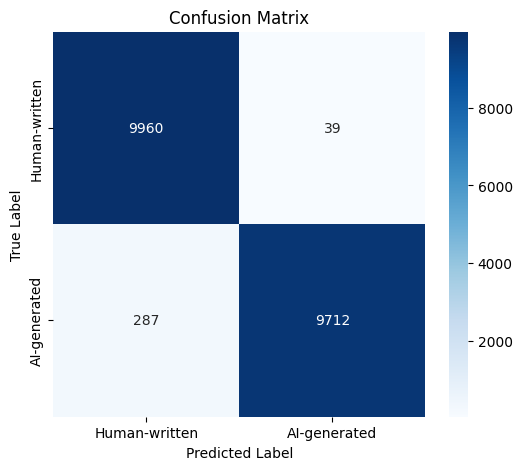

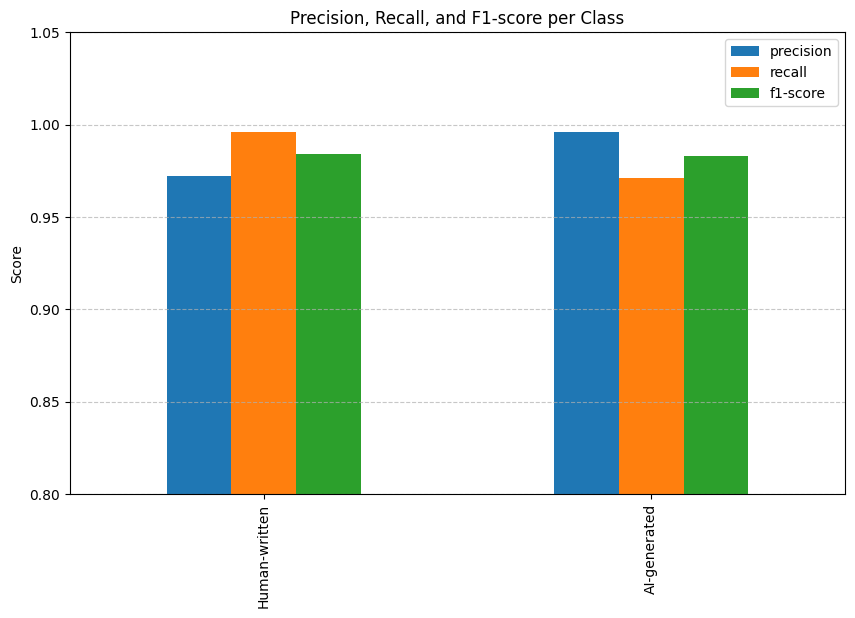

In [89]:
#VISUALIZATION CODE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Load your merged predictions file
df = pd.read_csv('ensemble_predictions_with_truth.csv')

# Ground truth and predictions
y_true = df['Label']
y_pred = df['Final_Ensemble_Label']

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['Human-written', 'AI-generated']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report as DataFrame
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)

# Plot Precision, Recall, F1-score
metrics = ['precision', 'recall', 'f1-score']
report_df.loc[labels, metrics].plot(kind='bar', figsize=(10, 6))
plt.title('Precision, Recall, and F1-score per Class')
plt.ylabel('Score')
plt.ylim(0.8, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [103]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # Ensures consistent results

def detect_lang_langdetect(text):
    try:
        return detect(text)  # returns ISO 639-1 language code (e.g., 'en', 'hi')
    except:
        return "unknown"


In [105]:
sample_texts = [
    "He has gone through serious health challenges, yet he keeps fighting...",
    "नमस्ते, आज मौसम बहुत अच्छा है।",
    "Bonjour, comment allez-vous aujourd'hui?",
    "سلام، حال شما چطور است؟",
    "evar thi ve nuvvu"
]

for text in sample_texts:
    lang = detect_lang_langdetect(text)
    print(f"\n Text: {text}")
    print(f" Detected Language: {lang.upper()}")



 Text: He has gone through serious health challenges, yet he keeps fighting...
 Detected Language: EN

 Text: नमस्ते, आज मौसम बहुत अच्छा है।
 Detected Language: HI

 Text: Bonjour, comment allez-vous aujourd'hui?
 Detected Language: FR

 Text: سلام، حال شما چطور است؟
 Detected Language: FA

 Text: evar thi ve nuvvu
 Detected Language: SQ


In [ ]:
#batch prediction for both bert + bert+rf with lang detect

In [107]:
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
from langdetect import detect
import joblib
from sklearn.ensemble import RandomForestClassifier
from transformers import BertModel


In [109]:
# Load fine-tuned BERT model
bert_finetuned_path = "bert_finetunedfixed_model"
tokenizer = BertTokenizer.from_pretrained(bert_finetuned_path)
bert_finetuned = BertForSequenceClassification.from_pretrained(bert_finetuned_path)
bert_finetuned.eval()

# Load BERT base model for embedding + RF
bert_base = BertModel.from_pretrained("bert-base-uncased")
bert_base.eval()
rf_model = joblib.load("bert_rf_model_fixed.joblib")

# Ensure CPU inference
device = torch.device("cpu")
bert_finetuned.to(device)
bert_base.to(device)


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [111]:
# BERT Fine-tuned prediction
def predict_bert_finetuned(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = bert_finetuned(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        confs = probs[:, 1].cpu().numpy()
    return preds, confs

# BERT embedding + RF prediction
def get_bert_embeddings(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = bert_base(**inputs)
    return outputs.pooler_output.cpu().numpy()

def predict_bert_rf(texts):
    embeddings = get_bert_embeddings(texts)
    preds = rf_model.predict(embeddings)
    confs = rf_model.predict_proba(embeddings)[:, 1]
    return preds, confs

# Language Detection
def detect_lang(text):
    try:
        return detect(text).upper()
    except:
        return "UNK"
sample_texts = [
    "For a good two hours, it was just chaos. Meetings back-to-back, everyone panicking, trying to figure out how we were going to hit our targets with even less. I felt a knot tightening in my chest, thinking about all the late nights and stress that were probably coming.",
    "Upon arrival, I was immediately apprised of unexpected budgetary constraints by a representative from the financial department. This information initially evoked a sensation of concern regarding potential operational adjustments and increased workload projections. ",
    "Bonjour, comment allez-vous aujourd'hui?",
    "سلام، حال شما چطور است؟",
    "evar thi ve nuvvu",
     "लेकिन जितना हमने इस बारे में बात की, उतना ही यह समझ आने लगा. ये एक बहुत बड़ा जोखिम था, लेकिन इसमें एक अजीब सी... रोमांचक बात भी थी.",
    "आज के दिन ने पेशेवर स्तर पर कई महत्वपूर्ण चुनौतियों को प्रस्तुत किया, जिनका अंततः एक उत्पादक समाधान हुआ. प्रातःकाल की शुरुआत कुछ मामूली व्यक्तिगत असुविधाओं के साथ हुई, जिनमें एक सिरदर्द और आकस्मिक पेय पदार्थ का गिरना शामिल था",
    "అబ్బా, ఏం రోజురా బాబు! నిజంగా చెప్పాలంటే, ఇంకా కొంచెం హై ఉంది, కానీ అది టెన్షన్ ది కాదు, మంచి హై. ఉదయం అంతా పూర్తిగా డిజాస్టర్ లా అనిపించింది. ",
    "చేరుకున్న వెంటనే, ఆర్థిక శాఖ నుండి ఒక ప్రతినిధి ద్వారా ఊహించని బడ్జెట్ కోతలను గురించి నాకు తెలియజేయబడింది. ఈ సమాచారం ప్రారంభంలో సంభావ్య కార్యకలాపాల సర్దుబాట్లు మరియు పెరిగిన పనిభారం అంచనాల గురించి ఆందోళనను కలిగించింది. పనిదినం యొక్క ప్రారంభ గంటలు సవరించిన ఆర్థిక నిబంధనలకు విభాగాన్ని అనుగుణంగా మార్చడానికి వ్యూహరచనపై దృష్టి సారించిన అనేక వరుస సమావేశాలతో కూడి ఉన్నాయి.",
    "அய்யோ, என்ன ஒரு நாள்! நேர்மையாக சொல்ல வேண்டுமானால், இன்னும் கொஞ்சம் பரபரப்பாகத்தான் இருக்கிறது, ஆனால் இப்போது அது பதட்டம் இல்லை, ஒரு நல்ல உணர்வு. இன்று காலை ஒரு முழுமையான பேரழிவாக இருந்தது.",
    "அளவுகோல்களுக்குத் துறையைத் தழுவிக்கொள்வதற்கான வியூகம் வகுப்பதில் கவனம் செலுத்திய பல தொடர்ச்சியான கூட்டங்களால் குறிக்கப்பட்டன. இந்தக் கலந்துரையாடல்களில் ஒரு வெளிப்படையான பதட்டமான சூழல் நிலவியது."
]
# Get predictions
preds_bert, confs_bert = predict_bert_finetuned(sample_texts)
preds_rf, confs_rf = predict_bert_rf(sample_texts)

# Average confidence
ensemble_confs = (confs_bert + confs_rf) / 2
ensemble_preds = (ensemble_confs >= 0.5).astype(int)

# Show results
for text, pred, conf, lang in zip(sample_texts, ensemble_preds, ensemble_confs, map(detect_lang, sample_texts)):
    label_str = "AI-generated" if pred == 1 else "Human-written"
    print(f"\n📝 Text: {text}")
    print(f" Detected Language: {lang}")
    print(f" Predicted: {label_str} (Label {pred})")
    print(f" Confidence: {conf:.4f}")



📝 Text: For a good two hours, it was just chaos. Meetings back-to-back, everyone panicking, trying to figure out how we were going to hit our targets with even less. I felt a knot tightening in my chest, thinking about all the late nights and stress that were probably coming.
 Detected Language: EN
 Predicted: Human-written (Label 0)
 Confidence: 0.2806

📝 Text: Upon arrival, I was immediately apprised of unexpected budgetary constraints by a representative from the financial department. This information initially evoked a sensation of concern regarding potential operational adjustments and increased workload projections. 
 Detected Language: EN
 Predicted: AI-generated (Label 1)
 Confidence: 0.8394

📝 Text: Bonjour, comment allez-vous aujourd'hui?
 Detected Language: FR
 Predicted: Human-written (Label 0)
 Confidence: 0.0451

📝 Text: سلام، حال شما چطور است؟
 Detected Language: FA
 Predicted: Human-written (Label 0)
 Confidence: 0.0151

📝 Text: evar thi ve nuvvu
 Detected Language: SQ

In [1]:
import torch
import numpy as np
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from langdetect import detect
import joblib

# Load fine-tuned BERT model and tokenizer
bert_model_path = "bert_finetunedfixed_model"
tokenizer = BertTokenizer.from_pretrained(bert_model_path)
bert_model = BertForSequenceClassification.from_pretrained(bert_model_path)
bert_model.eval()

# Load RandomForest model trained on CLS embeddings
rf_model = joblib.load("bert_rf_cls_final.joblib")

# Input texts
texts = [
         "The preliminary data analysis indicates a statistically significant correlation between increased solar flare activity and transient disruptions in global satellite communication networks. ",
          "Our Q2 operational review highlights sustained growth in market penetration, primarily attributable to the successful deployment of our revised digital marketing strategy. Key performance indicators demonstrate a 12% increase in customer acquisition and a 7% improvement in user engagement metrics. ",
          "The Xylo-Drone 5000 features an advanced gyroscopic stabilization system and integrated high-definition optical sensors, facilitating unparalleled aerial maneuverability and precise data acquisition.",
          "Authorities urge continued vigilance and adherence to official advisories as floodwaters recede and damage assessments commence across affected municipalities.Authorities urge continued vigilance and adherence to official advisories as floodwaters recede and damage assessments commence across affected municipalities.",
          "what the hell is wrong with you"
]

# Results list
rows = []

for text in texts:
    lang = detect(text)

    # Tokenize and predict with BERT          
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
    with torch.no_grad():
        outputs = bert_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[0].numpy()
        pred_label = np.argmax(probs)
        conf_bert = round(probs[pred_label] * 100, 2)
        label_bert = "AI" if pred_label == 1 else "Human"

        # Extract CLS embedding from BERT encoder
        hidden = bert_model.bert(**inputs).last_hidden_state
        cls_embedding = hidden[:, 0, :].numpy()

        # Predict with RF using CLS embedding
        pred_rf = rf_model.predict(cls_embedding)[0]
        conf_rf = round(np.max(rf_model.predict_proba(cls_embedding)) * 100, 2)
        label_rf = "AI" if pred_rf == 1 else "Human"

    # Final decision
    if lang != "en":
        final_label = "Human"
    elif conf_bert >= 85:
        final_label = label_bert
    else:
        final_label = label_rf

    rows.append({
        "Original Text": text,
        "Language": lang,
        "BERT Label": label_bert,
        "BERT Conf": conf_bert,
        "RF Label": label_rf,
        "RF Conf": conf_rf,
        "Final Label": final_label
    })

# Convert to DataFrame
df = pd.DataFrame(rows)

# ----- Apply Styling -----
def style_results(df):
    return df.style \
        .set_properties(**{
            'text-align': 'center',
            'white-space': 'pre-wrap'
        }) \
        .set_table_styles([{
            'selector': 'th',
            'props': [('font-weight', 'bold'), ('text-align', 'center')]
        }]) \
        .format({
            "BERT Conf": "{:.2f}",
            "RF Conf": "{:.2f}"
        })

# Display styled table (only works in Jupyter/Colab)
styled_df = style_results(df)
styled_df


C:\Users\sonia\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\sonia\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Original Text,Language,BERT Label,BERT Conf,RF Label,RF Conf,Final Label
0,The preliminary data analysis indicates a statistically significant correlation between increased solar flare activity and transient disruptions in global satellite communication networks.,en,AI,99.92,AI,62.00,AI
1,"Our Q2 operational review highlights sustained growth in market penetration, primarily attributable to the successful deployment of our revised digital marketing strategy. Key performance indicators demonstrate a 12% increase in customer acquisition and a 7% improvement in user engagement metrics.",en,AI,99.91,AI,60.00,AI
2,"The Xylo-Drone 5000 features an advanced gyroscopic stabilization system and integrated high-definition optical sensors, facilitating unparalleled aerial maneuverability and precise data acquisition.",en,AI,99.90,AI,61.00,AI
3,Authorities urge continued vigilance and adherence to official advisories as floodwaters recede and damage assessments commence across affected municipalities.Authorities urge continued vigilance and adherence to official advisories as floodwaters recede and damage assessments commence across affected municipalities.,en,AI,99.88,AI,67.00,AI
4,what the hell is wrong with you,en,Human,99.96,Human,75.00,Human


In [ ]:
#bundle your current BERT + RF prediction pipeline
#predict_pipeline.py

In [2]:
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
from langdetect import detect
import joblib

# Load models once at the top (global scope)
bert_model_path = "bert_finetunedfixed_model"
tokenizer = BertTokenizer.from_pretrained(bert_model_path)
bert_model = BertForSequenceClassification.from_pretrained(bert_model_path)
bert_model.eval()

rf_model = joblib.load("bert_rf_cls_final.joblib")


def predict_batch(texts):
    results = []

    for text in texts:
        lang = detect(text)

        # BERT prediction
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
        with torch.no_grad():
            logits = bert_model(**inputs).logits
            probs = torch.softmax(logits, dim=1)[0].numpy()
            pred_label = np.argmax(probs)
            conf_bert = round(probs[pred_label] * 100, 2)
            label_bert = "AI" if pred_label == 1 else "Human"

            # Get CLS embeddings for RF
            hidden = bert_model.bert(**inputs).last_hidden_state
            cls_embedding = hidden[:, 0, :].numpy()

            pred_rf = rf_model.predict(cls_embedding)[0]
            conf_rf = round(np.max(rf_model.predict_proba(cls_embedding)) * 100, 2)
            label_rf = "AI" if pred_rf == 1 else "Human"

        # Final decision logic
        if lang != "en":
            final_label = "Human"
        elif conf_bert >= 85:
            final_label = label_bert
        else:
            final_label = label_rf

        results.append({
            "Original Text": text,
            "Language": lang,
            "BERT Label": label_bert,
            "BERT Conf": conf_bert,
            "RF Label": label_rf,
            "RF Conf": conf_rf,
            "Final Label": final_label
        })

    return results


C:\Users\sonia\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\sonia\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
#Run batch predictions

In [3]:
texts = [
    "Together, we will rebuild the credibility of all institutions.",
    "मां के जनाजे में शामिल होने पाकिस्तान जाना चाहिए।",
    "The Xylo-Drone 5000 features an advanced gyroscopic stabilization system and integrated high-definition optical sensors, facilitating unparalleled aerial maneuverability and precise data acquisition.",
    "ఈ డిజిటల్ డేటా ఆధారిత యుగంలో, డేటా ప్రాసెసింగ్ అనేది కృత్రిమ మేథస్సు వ్యవస్థల యొక్క మూల ఆధారంగా పరిగణించబడుతుంది. ఒక యంత్రం అర్థవంతమైన నిర్ణయాలు తీసుకోవాలంటే, అది విశ్వసనీయమైన, నిర్మలమైన, మరియు సముచితమైన డేటాను అందించవలసిన అవసరం ఉంది. ",
    "ఇది కేవలం సాంకేతిక ప్రయోగం కాదు — ఇది సమాజాన్ని ప్రభావితం చేసే సామర్థ్యం కలిగిన మార్గం. మరెన్నో లెక్కలలో ఈ వ్యవస్థలు విశ్వాన్ని మార్చే శక్తిని కలిగి వున్నా, అవి తగిన నిబంధనలు లేకుండా విడుదలైతే, అవి అపరిచితమైన మరియు అవాంఛనీయమైన ఫలితాలను తేవచ్చు.",
    "చాలాసార్లు మనం పెద్ద పెద్ద కలల మీదే దృష్టి పెడుతుంటాం. పెద్ద ఉద్యోగం కావాలి, మంచి ఇల్లు కావాలి, చాలా డబ్బు కావాలి. కానీ, నిజంగా మనసును తాకే ఆనందం ఎప్పుడూ చిన్న చిన్న క్షణాల్లోనే దొరుకుతుంది. ఉదయం వేళ ఒక కప్పు వేడిచాయ, ఓ ఊహించని ఫోన్ కాల్, చిన్ని నవ్వుతో పిల్లగాడు చేసిన ఏదైనా కామెడీ, వానకాలంలో మట్టి వాసన... ఇవన్నీ జీవితాన్ని బంగారం లా చేస్తాయి.",
    " Un café caliente en la mañana, el olor del pan recién hecho, una conversación sin prisa",
    "El tiempo no avisa, simplemente pasa. Y por eso, cada instante cuenta. A veces duele crecer, aceptar que ciertas etapas ya no van a volver. Pero también hay algo hermoso en eso: cada etapa tiene su encanto, sus enseñanzas, sus personas. Lo importante es estar presente, vivir sin miedo a sentir.",
    "ഡാറ്റ ഇല്ലാതെ യാതൊരു കൃത്രിമ ബുദ്ധിയും കൃത്യമായ നിഗമനങ്ങൾ അവതരിപ്പിക്കാൻ അർഹതപെടുകയില്ല. അതിനാൽ, ഡാറ്റ ശേഖരണം, ശുദ്ധീകരണം, ലേബലിംഗും ഉൾപ്പെടെയുള്ള പ്രക്രിയകൾ കൃത്രിമ ബുദ്ധി വളർച്ചയുടെ അടിസ്ഥാനം ആകുന്നു.",
    "ഈ തരത്തിലുള്ള recursive learning സംവിധാനങ്ങൾ ആശയപരമായി വളരെ ശക്തമായവയാണെങ്കിലും അവയെ നിയന്ത്രിക്കേണ്ടതിന്റെ ആവശ്യകത അത്ര തന്നെ ഗൗരവപ്പെട്ടതാണ്. നിയന്ത്രണരഹിതമായി ഇത്തരം സംവിധാനങ്ങൾ വികാസം"
]

results = predict_batch(texts)

import pandas as pd
df = pd.DataFrame(results)
df


,Original Text,Language,BERT Label,BERT Conf,RF Label,RF Conf,Final Label
0,"Together, we will rebuild the credibility of a...",en,Human,99.62,Human,60.0,Human
1,मां के जनाजे में शामिल होने पाकिस्तान जाना चाहिए।,hi,Human,99.97,Human,73.0,Human
2,The Xylo-Drone 5000 features an advanced gyros...,en,AI,99.90,AI,61.0,AI
3,"ఈ డిజిటల్ డేటా ఆధారిత యుగంలో, డేటా ప్రాసెసింగ్...",te,Human,99.97,Human,72.0,Human
4,ఇది కేవలం సాంకేతిక ప్రయోగం కాదు — ఇది సమాజాన్న...,te,Human,99.97,Human,71.0,Human
5,చాలాసార్లు మనం పెద్ద పెద్ద కలల మీదే దృష్టి పెడ...,te,Human,99.97,Human,71.0,Human
6,"Un café caliente en la mañana, el olor del pa...",es,Human,99.97,Human,74.0,Human
7,"El tiempo no avisa, simplemente pasa. Y por es...",es,Human,99.95,Human,67.0,Human
8,ഡാറ്റ ഇല്ലാതെ യാതൊരു കൃത്രിമ ബുദ്ധിയും കൃത്യമാ...,ml,Human,99.97,Human,70.0,Human
9,ഈ തരത്തിലുള്ള recursive learning സംവിധാനങ്ങൾ ആ...,ml,Human,99.98,Human,75.0,Human


In [121]:
code = '''
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
from langdetect import detect
import joblib

# Load models once
bert_model_path = "bert_finetuned1_model"
tokenizer = BertTokenizer.from_pretrained(bert_model_path)
bert_model = BertForSequenceClassification.from_pretrained(bert_model_path)
bert_model.eval()
rf_model = joblib.load("bert_rf_model_small.joblib")

def predict_batch(texts):
    results = []
    for text in texts:
        lang = detect(text)
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
        with torch.no_grad():
            logits = bert_model(**inputs).logits
            probs = torch.softmax(logits, dim=1)[0].numpy()
            pred_label = np.argmax(probs)
            conf_bert = round(probs[pred_label] * 100, 2)
            label_bert = "AI" if pred_label == 1 else "Human"

            hidden = bert_model.bert(**inputs).last_hidden_state
            cls_embedding = hidden[:, 0, :].numpy()
            pred_rf = rf_model.predict(cls_embedding)[0]
            conf_rf = round(np.max(rf_model.predict_proba(cls_embedding)) * 100, 2)
            label_rf = "AI" if pred_rf == 1 else "Human"

        if lang != "en":
            final_label = "Human"
        elif conf_bert >= 85:
            final_label = label_bert
        else:
            final_label = label_rf

        results.append({
            "Original Text": text,
            "Language": lang,
            "BERT Label": label_bert,
            "BERT Conf": conf_bert,
            "RF Label": label_rf,
            "RF Conf": conf_rf,
            "Final Label": final_label
        })
    return results
'''

# Save to file
with open("predictor.py", "w", encoding="utf-8") as f:
    f.write(code)
print("✅ predictor.py saved!")


✅ predictor.py saved!


In [ ]:
#Verifying in Jupyter

In [125]:
from predictor import predict_batch

# Test
predict_batch(["In the context of modern digital frameworks, the integration of artificial intelligence into human productivity workflows has demonstrated statistically significant enhancements in both efficiency and operational", "Whoever reading this comment, i wish you will get your loved one and stay happy throughout your life","अतः, कृत्रिम बुद्धिमत्ता कोई साधारण तकनीकी उपकरण नहीं है, बल्कि यह एक उन्नत गणनात्मक सहायक प्रणाली के रूप में कार्य करती है, जो समय के साथ कार्य की गति और गुणवत्ता दोनों में वृद्धि करती है।"])


[{'Original Text': 'In the context of modern digital frameworks, the integration of artificial intelligence into human productivity workflows has demonstrated statistically significant enhancements in both efficiency and operational',
  'Language': 'en',
  'BERT Label': 'Human',
  'BERT Conf': 64.91,
  'RF Label': 'Human',
  'RF Conf': 59.0,
  'Final Label': 'Human'},
 {'Original Text': 'Whoever reading this comment, i wish you will get your loved one and stay happy throughout your life',
  'Language': 'en',
  'BERT Label': 'Human',
  'BERT Conf': 66.68,
  'RF Label': 'AI',
  'RF Conf': 59.0,
  'Final Label': 'AI'},
 {'Original Text': 'अतः, कृत्रिम बुद्धिमत्ता कोई साधारण तकनीकी उपकरण नहीं है, बल्कि यह एक उन्नत गणनात्मक सहायक प्रणाली के रूप में कार्य करती है, जो समय के साथ कार्य की गति और गुणवत्ता दोनों में वृद्धि करती है।',
  'Language': 'hi',
  'BERT Label': 'Human',
  'BERT Conf': 64.77,
  'RF Label': 'AI',
  'RF Conf': 56.0,
  'Final Label': 'Human'}]

In [ ]:
#Bundle Into an API

In [ ]:
#Build a Minimal Flask API

In [127]:
from flask import Flask, request, jsonify
from predictor import predict_batch  # Make sure predictor.py is in the same folder

app = Flask(__name__)

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json
    texts = data.get("texts", [])
    results = predict_batch(texts)
    return jsonify(results)

if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#run it in Jupyter:

In [1]:
pip install shap


   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   --------------------------------------- 545.2/545.2 kB 17.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
